In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

image = cv2.imread("C:/Users/Lenovo/Desktop/week9/add noise  image.png", 0)

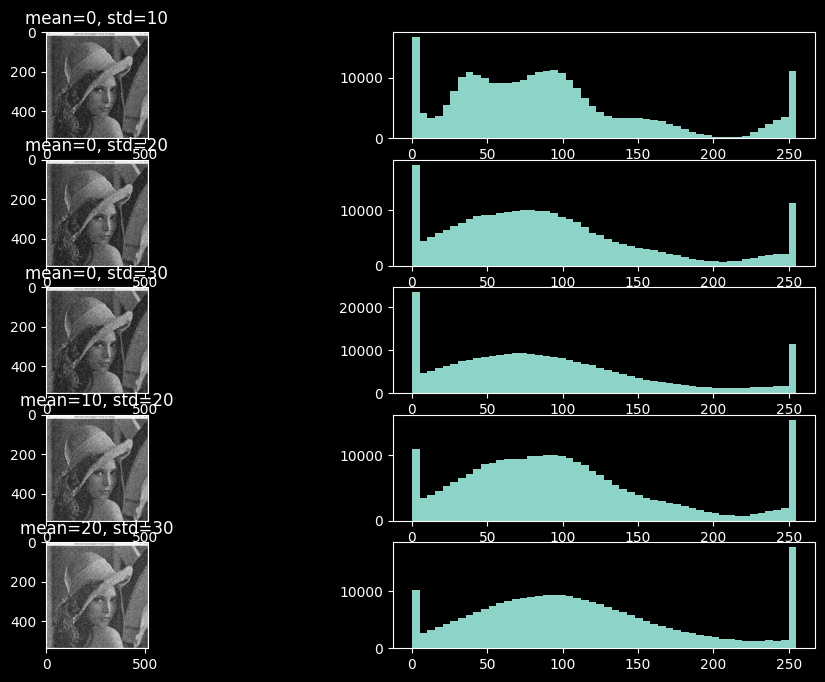

In [19]:
params = [(0,10),(0,20),(0,30),(10,20),(20,30)]

plt.figure(figsize=(12,8))

for i,(m,s) in enumerate(params):
    noisy = np.clip(image + np.random.normal(m,s,image.shape),0,255)

    plt.subplot(5,2,2*i+1)
    plt.imshow(noisy, cmap='gray')
    plt.title(f"mean={m}, std={s}")

    plt.subplot(5,2,2*i+2)
    plt.hist(noisy.ravel(), bins=50)

plt.show()

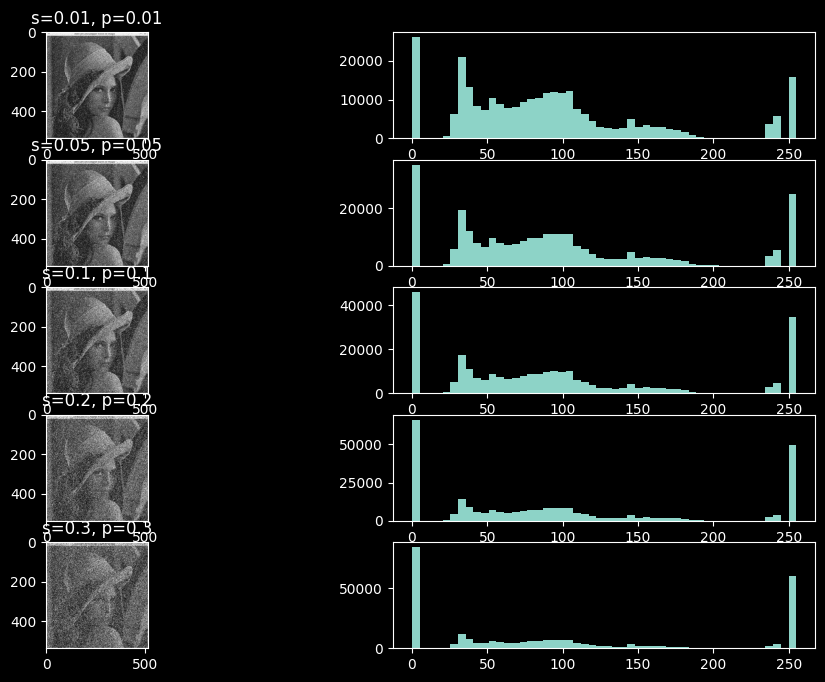

In [20]:
probs = [(0.01,0.01),(0.05,0.05),(0.1,0.1),(0.2,0.2),(0.3,0.3)]

plt.figure(figsize=(12,8))

for i,(s,p) in enumerate(probs):
    noisy = image.copy()

    num = int(s*image.size)
    coords = [np.random.randint(0,i-1,num) for i in image.shape]
    noisy[coords[0],coords[1]] = 255

    num = int(p*image.size)
    coords = [np.random.randint(0,i-1,num) for i in image.shape]
    noisy[coords[0],coords[1]] = 0

    plt.subplot(5,2,2*i+1)
    plt.imshow(noisy, cmap='gray')
    plt.title(f"s={s}, p={p}")

    plt.subplot(5,2,2*i+2)
    plt.hist(noisy.ravel(), bins=50)

plt.show()

In [4]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy_image = image.copy()

    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255

    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0

    return noisy_image

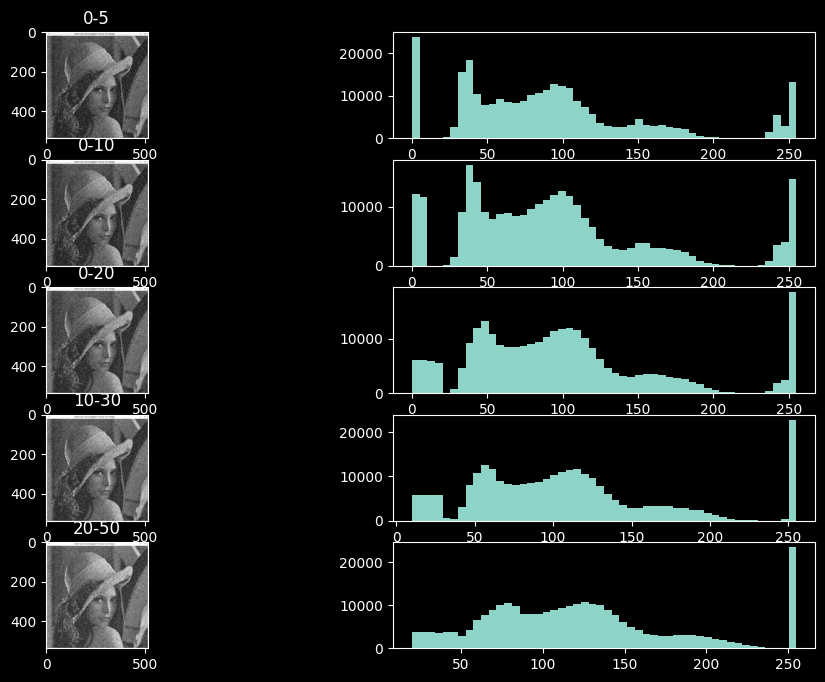

In [21]:
ranges = [(0,5),(0,10),(0,20),(10,30),(20,50)]

plt.figure(figsize=(12,8))

for i,(l,h) in enumerate(ranges):
    noisy = np.clip(image + np.random.uniform(l,h,image.shape),0,255)

    plt.subplot(5,2,2*i+1)
    plt.imshow(noisy, cmap='gray')
    plt.title(f"{l}-{h}")

    plt.subplot(5,2,2*i+2)
    plt.hist(noisy.ravel(), bins=50)

plt.show()

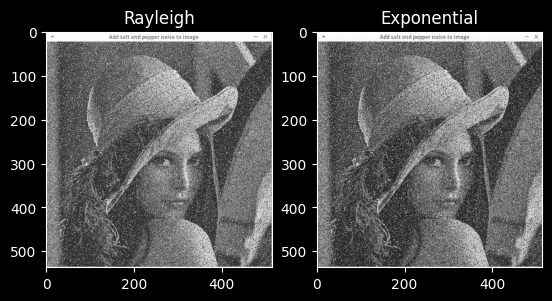

In [22]:
ray = np.clip(image + np.random.rayleigh(20,image.shape),0,255)
exp = np.clip(image + np.random.exponential(20,image.shape),0,255)

plt.subplot(1,2,1)
plt.imshow(ray, cmap='gray')
plt.title("Rayleigh")

plt.subplot(1,2,2)
plt.imshow(exp, cmap='gray')
plt.title("Exponential")

plt.show()

In [23]:
def median_filter(img,k):
    pad=k//2
    p=np.pad(img,pad,mode='symmetric')
    out=np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            out[i,j]=np.median(p[i:i+k,j:j+k])
    return out

def mean_filter(img,k):
    return cv2.blur(img,(k,k))

def geometric_filter(img,k):
    pad=k//2
    p=np.pad(img,pad,mode='symmetric')
    out=np.zeros_like(img,dtype=float)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            patch=p[i:i+k,j:j+k]
            out[i,j]=np.exp(np.mean(np.log(patch+1)))
    return out

def harmonic_filter(img,k):
    pad=k//2
    p=np.pad(img,pad,mode='symmetric')
    out=np.zeros_like(img,dtype=float)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            patch=p[i:i+k,j:j+k]
            out[i,j]=(k*k)/np.sum(1/(patch+1))
    return out

def min_filter(img,k):
    return cv2.erode(img,np.ones((k,k)))

def max_filter(img,k):
    return cv2.dilate(img,np.ones((k,k)))

In [8]:
def apply_box(image_input, box, filt_size):
    pad_size = int(np.floor(filt_size / 2))

    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')

    image_box = copy.deepcopy(image_input)

    row, column = image_input.shape

    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i, j] = np.sum(results_box)

    return image_box

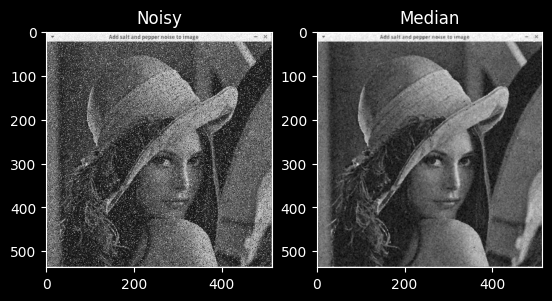

In [24]:
g = np.clip(image + np.random.normal(0,20,image.shape),0,255)
f = median_filter(g,3)

plt.subplot(1,2,1); plt.imshow(g,cmap='gray'); plt.title("Noisy")
plt.subplot(1,2,2); plt.imshow(f,cmap='gray'); plt.title("Median")
plt.show()

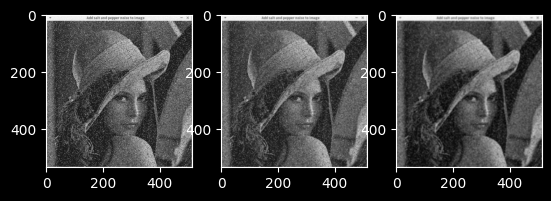

In [25]:
g = np.clip(image + np.random.normal(0,10,image.shape),0,255)

f1 = mean_filter(g,3)
f2 = mean_filter(g,5)

plt.subplot(1,3,1); plt.imshow(g,cmap='gray')
plt.subplot(1,3,2); plt.imshow(f1,cmap='gray')
plt.subplot(1,3,3); plt.imshow(f2,cmap='gray')
plt.show()

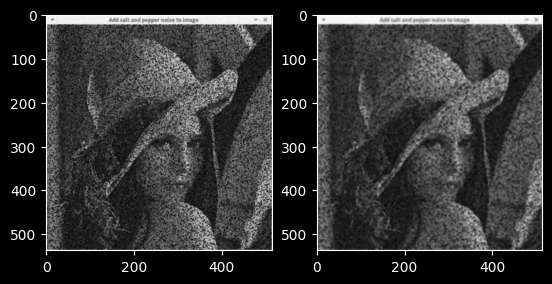

In [26]:
f1 = geometric_filter(g,3)
f2 = geometric_filter(g,5)

plt.subplot(1,2,1); plt.imshow(f1,cmap='gray')
plt.subplot(1,2,2); plt.imshow(f2,cmap='gray')
plt.show()

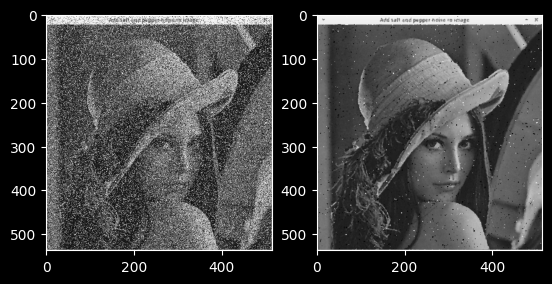

In [27]:
sp = image.copy()
coords = [np.random.randint(0,i-1,int(0.1*image.size)) for i in image.shape]
sp[coords[0],coords[1]]=255

coords = [np.random.randint(0,i-1,int(0.1*image.size)) for i in image.shape]
sp[coords[0],coords[1]]=0

f = median_filter(sp,3)

plt.subplot(1,2,1); plt.imshow(sp,cmap='gray')
plt.subplot(1,2,2); plt.imshow(f,cmap='gray')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16020\3242380819.py:30: RuntimeWarning: divide by zero encountered in divide
  out[i,j]=(k*k)/np.sum(1/(patch+1))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16020\3242380819.py:20: RuntimeWarning: divide by zero encountered in log
  out[i,j]=np.exp(np.mean(np.log(patch+1)))


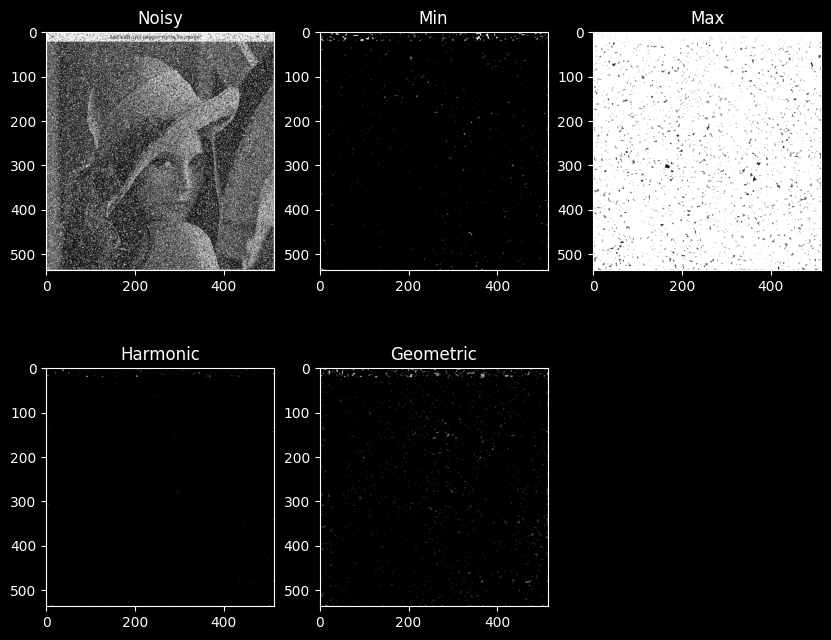

In [28]:
sp = image.copy()
coords = [np.random.randint(0,i-1,int(0.1*image.size)) for i in image.shape]
sp[coords[0],coords[1]]=255
coords = [np.random.randint(0,i-1,int(0.1*image.size)) for i in image.shape]
sp[coords[0],coords[1]]=0

min_f = min_filter(sp,5)
max_f = max_filter(sp,5)
harm_f = harmonic_filter(sp,5)
geo_f = geometric_filter(sp,5)

plt.figure(figsize=(10,8))

plt.subplot(2,3,1); plt.imshow(sp,cmap='gray'); plt.title("Noisy")
plt.subplot(2,3,2); plt.imshow(min_f,cmap='gray'); plt.title("Min")
plt.subplot(2,3,3); plt.imshow(max_f,cmap='gray'); plt.title("Max")
plt.subplot(2,3,4); plt.imshow(harm_f,cmap='gray'); plt.title("Harmonic")
plt.subplot(2,3,5); plt.imshow(geo_f,cmap='gray'); plt.title("Geometric")

plt.show()